In [1]:
import pandas as pd
import config as cfg
import numpy as np
import matplotlib.pyplot as plt

In [2]:
passenger = pd.read_csv(cfg.PASSENGERS_CLEAN_OUT)
cases = pd.read_csv(cfg.CASES_CLEAN_OUT)

In [3]:
cases.columns

Index(['event_type', 'arrival_airport_code', 'departure_airport_code',
       'departure_date', 'arrival_airport_name', 'departure_airport_name',
       'arrival_city_name', 'departure_city_name', 'departure_country_code',
       'alarm_reason', 'departure_country_name', 'arrival_country_code',
       'region_zone', 'arrival_country_name', 'total_flights'],
      dtype='object')

In [4]:
passenger.columns

Index(['arrival_airport_code', 'departure_airport_code', 'departure_date',
       'arrival_airport_name', 'departure_airport_name', 'arrival_city',
       'departure_city', 'arrival_country_code', 'departure_country_code',
       'arrival_country', 'departure_country', 'zone',
       'passengers_entries_count', 'passengers_investigated_count',
       'passengers_flagged_count', 'gender', 'transit_flag', 'control_result',
       'document_type', 'age_range', 'nationality', 'airline',
       'flight_number'],
      dtype='object')

Time based features: year, month, day, hour, weekday and is_weekend

In [5]:
passenger["departure_date"] = pd.to_datetime(passenger["departure_date"], errors="coerce")
cases["departure_date"] = pd.to_datetime(cases["departure_date"], errors="coerce")

passenger["year"] = passenger["departure_date"].dt.year
passenger["month"] = passenger["departure_date"].dt.month
passenger["day"] = passenger["departure_date"].dt.day
passenger["hour"] = passenger["departure_date"].dt.hour
passenger["weekday"] = passenger["departure_date"].dt.dayofweek   #Monday is 0
passenger["is_weekend"] = passenger["weekday"].isin([5, 6]).astype(int)

cases["year"] = cases["departure_date"].dt.year
cases["month"] = cases["departure_date"].dt.month
cases["day"] = cases["departure_date"].dt.day
cases["hour"] = cases["departure_date"].dt.hour
cases["weekday"] = cases["departure_date"].dt.dayofweek
cases["is_weekend"] = cases["weekday"].isin([5, 6]).astype(int)

passenger["date"] = passenger["departure_date"].dt.floor("D")
cases["date"] = cases["departure_date"].dt.floor("D")

passenger["document_type"] = passenger["document_type"].fillna("UNKNOWN")
cases["alarm_reason"] = cases["alarm_reason"].fillna("UNKNOWN")

Route based features: route_country, route_city and route_airport

In [6]:
passenger["route_country"] = passenger["departure_country_code"].astype(str) + "_" + passenger["arrival_country_code"].astype(str)
passenger["route_city"] = passenger["departure_city"].astype(str) + "_" + passenger["arrival_city"].astype(str)
passenger["route_airport"] = passenger["departure_airport_code"].astype(str) + "_" + passenger["arrival_airport_code"].astype(str)

cases["route_country"] = cases["departure_country_code"].astype(str) + "_" + cases["arrival_country_code"].astype(str)
cases["route_city"] = cases["departure_city_name"].astype(str) + "_" + cases["arrival_city_name"].astype(str)
cases["route_airport"] = cases["departure_airport_code"].astype(str) + "_" + cases["arrival_airport_code"].astype(str)

Ratio based features: investigation_rate, flag_rate and flag_given_investigated
Since there are suspicous rows which are having a very low amount of entries, it's <br>
better to not rely on them directly. A new feature is added in order to be able to filter it later on.

In [7]:
passenger["is_low_volume"] = (passenger["passengers_entries_count"] < 10).astype(int)

passenger["investigation_rate"] = np.where(passenger["passengers_entries_count"] > 0, passenger["passengers_investigated_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_rate"] = np.where(passenger["passengers_entries_count"] > 0, passenger["passengers_flagged_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_given_investigated"] = np.where(passenger["passengers_investigated_count"] > 0, passenger["passengers_flagged_count"] / passenger["passengers_investigated_count"], np.nan)

### Base Table
Building a core daily route table

In [8]:
route_daily = (passenger.groupby(["date", "route_airport"], as_index=False)
    .agg(route_city=("route_city", "first"),
        route_country=("route_country", "first"),
        entries=("passengers_entries_count", "sum"),
        investigated=("passengers_investigated_count", "sum"),
        flagged=("passengers_flagged_count", "sum")
    ))

route_daily["investigation_rate"] = np.where(route_daily["entries"] > 0, route_daily["investigated"] / route_daily["entries"], np.nan)
route_daily["flag_rate"] = np.where(route_daily["entries"] > 0, route_daily["flagged"] / route_daily["entries"], np.nan)
route_daily["flag_given_investigated"] = np.where(route_daily["investigated"] > 0, route_daily["flagged"] / route_daily["investigated"], np.nan)

route_daily["year"] = route_daily["date"].dt.year
route_daily["month"] = route_daily["date"].dt.month
route_daily["day"] = route_daily["date"].dt.day
route_daily["weekday"] = route_daily["date"].dt.dayofweek
route_daily["is_weekend"] = route_daily["weekday"].isin([5, 6]).astype(int)

route_daily.head()

,date,route_airport,route_city,route_country,entries,investigated,flagged,investigation_rate,flag_rate,flag_given_investigated,year,month,day,weekday,is_weekend
0,2023-12-31,JFK_FCO,NEW YORK_ROMA,USA_ITA,3,3,0,1.0,0.0,0.0,2023,12,31,6,1
1,2024-01-01,ADB_MXP,SMIRNE_MILANO,TUR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
2,2024-01-01,AMM_FCO,AMMAN_ROMA,JOR_ITA,2,0,0,0.0,0.0,NaN,2024,1,1,0,0
3,2024-01-01,BEG_BGY,BELGRADO_BERGAMO,SRB_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
4,2024-01-01,BFS_BGY,BELFAST_BERGAMO,GBR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0


### Daily Route + Nationality Features
First a table based on route_city + nationality is created and then will be merged with the base table.

In [9]:
route_nat_daily = (passenger.groupby(["date", "route_airport", "nationality"], as_index=False)
                .agg(nat_entries=("passengers_entries_count", "sum"),
                    nat_investigated=("passengers_investigated_count", "sum"),
                    nat_flagged=("passengers_flagged_count", "sum")))

route_nat_daily["nat_investigation_rate"] = np.where(route_nat_daily["nat_entries"] > 0, route_nat_daily["nat_investigated"] / route_nat_daily["nat_entries"],np.nan)
route_nat_daily["nat_flag_rate"] = np.where(route_nat_daily["nat_entries"] > 0, route_nat_daily["nat_flagged"] / route_nat_daily["nat_entries"],np.nan)

In [10]:
nat_features = (route_nat_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(nationality_count=("nationality", "nunique"),
        avg_nat_entries=("nat_entries", "mean"),
        max_nat_entries=("nat_entries", "max"),
        avg_nat_flag_rate=("nat_flag_rate", "mean"),
        max_nat_flag_rate=("nat_flag_rate", "max")))

route_daily = route_daily.merge(nat_features,on=["date", "route_airport"],how="left")

Document Type Features

In [11]:
route_doc_daily = (passenger.groupby(["date", "route_airport", "document_type"], as_index=False)
    .agg(doc_entries=("passengers_entries_count", "sum"),
        doc_investigated=("passengers_investigated_count", "sum"),
        doc_flagged=("passengers_flagged_count", "sum")))

route_doc_daily["doc_investigation_rate"] = np.where(route_doc_daily["doc_entries"] > 0, route_doc_daily["doc_investigated"] / route_doc_daily["doc_entries"],np.nan)
route_doc_daily["doc_flag_rate"] = np.where(route_doc_daily["doc_entries"] > 0, route_doc_daily["doc_flagged"] / route_doc_daily["doc_entries"],np.nan)

doc_features = (route_doc_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(document_type_count=("document_type", "nunique"),
        avg_doc_entries=("doc_entries", "mean"),
        max_doc_entries=("doc_entries", "max"),
        avg_doc_flag_rate=("doc_flag_rate", "mean"),
        max_doc_flag_rate=("doc_flag_rate", "max")))

route_daily = route_daily.merge(doc_features,on=["date", "route_airport"],how="left")

Airline Features

In [12]:
route_airline_daily = (passenger.groupby(["date", "route_airport", "airline"], as_index=False)
        .agg(airline_entries=("passengers_entries_count", "sum"),
        airline_investigated=("passengers_investigated_count", "sum"),
        airline_flagged=("passengers_flagged_count", "sum")))

route_airline_daily["airline_flag_rate"] = np.where(route_airline_daily["airline_entries"] > 0, route_airline_daily["airline_flagged"] / route_airline_daily["airline_entries"],np.nan)

airline_features = (route_airline_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(airline_count=("airline", "nunique"),
        avg_airline_entries=("airline_entries", "mean"),
        max_airline_entries=("airline_entries", "max"),
        avg_airline_flag_rate=("airline_flag_rate", "mean"),
        max_airline_flag_rate=("airline_flag_rate", "max")))

route_daily = route_daily.merge(airline_features,on=["date", "route_airport"],how="left")

Control Results Features

In [13]:
route_control_daily = (passenger.groupby(["date", "route_airport", "control_result"], dropna=False, as_index=False)
    .agg(control_entries=("passengers_entries_count", "sum"),
        control_investigated=("passengers_investigated_count", "sum"),
        control_flagged=("passengers_flagged_count", "sum")))

route_control_daily["control_flag_rate"] = np.where(route_control_daily["control_entries"] > 0,route_control_daily["control_flagged"] / route_control_daily["control_entries"],np.nan)

control_features = (route_control_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(control_result_count=("control_result", "nunique"),
        avg_control_entries=("control_entries", "mean"),
        max_control_entries=("control_entries", "max"),
        avg_control_flag_rate=("control_flag_rate", "mean"),
        max_control_flag_rate=("control_flag_rate", "max")))

route_daily = route_daily.merge(control_features,on=["date", "route_airport"],how="left")

Cases Dataset Features + Merge on the main table

In [14]:
cases_route_daily = (cases.groupby(["date", "route_airport"], as_index=False)
    .agg(case_records=("event_type", "size"),
        total_flights=("total_flights", "sum"),
        unique_alarm_reasons=("alarm_reason", "nunique"),
        unique_event_types=("event_type", "nunique")))

route_daily = route_daily.merge(cases_route_daily,on=["date", "route_airport"],how="left")

route_daily["has_case_match"] = route_daily["case_records"].notna().astype(int)
route_daily["alarm_density_per_entry"] = np.where(route_daily["entries"] > 0,route_daily["case_records"] / route_daily["entries"],np.nan)

route_daily = route_daily.sort_values(["route_airport", "date"]).reset_index(drop=True)

Changes in Features
In order to observe trends in the change of entries and change of flag rate over time, the top 3 routes are visualized.

In [15]:
change_cols = ["entries", "investigated", "flagged", "investigation_rate", "flag_rate"]

for col in change_cols:
    route_daily[f"{col}_lag1"] = route_daily.groupby("route_airport")[col].shift(1)
    route_daily[f"{col}_diff1"] = route_daily[col] - route_daily[f"{col}_lag1"]
    route_daily[f"{col}_pct_change1"] = np.where(route_daily[f"{col}_lag1"].notna() & (route_daily[f"{col}_lag1"] != 0),
        (route_daily[col] - route_daily[f"{col}_lag1"]) / route_daily[f"{col}_lag1"],np.nan)

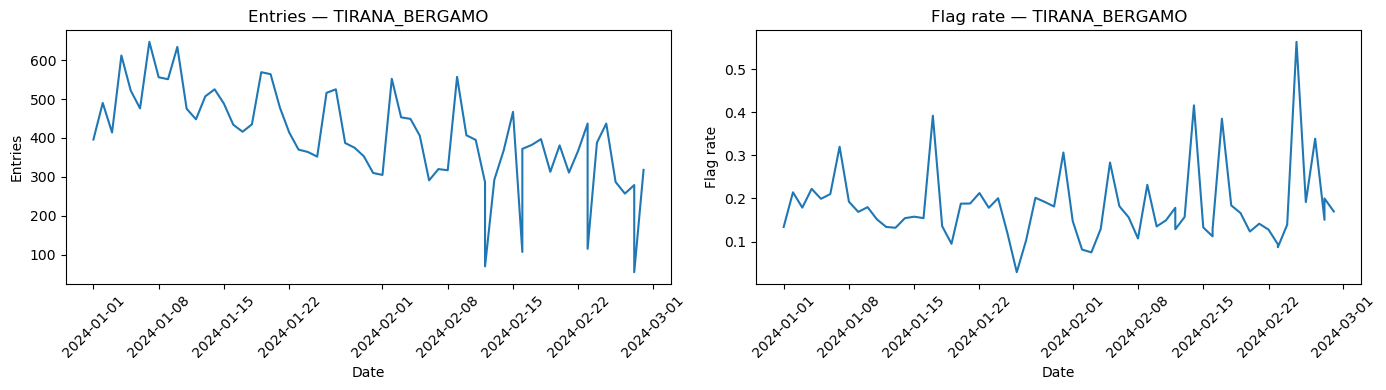

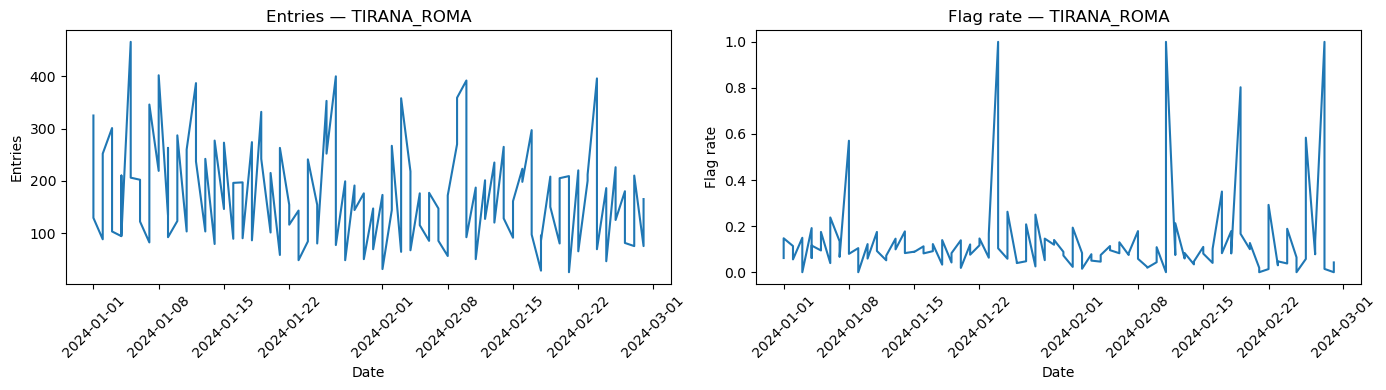

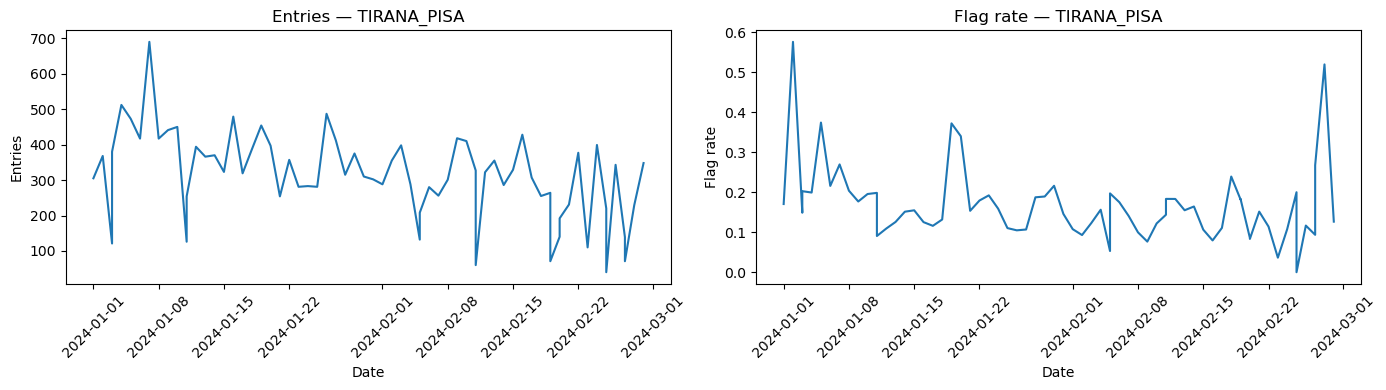

In [ ]:
top_routes = route_daily.groupby("route_city")["entries"].sum().sort_values(ascending=False).head(3).index.tolist()

for route in top_routes:
    tmp = route_daily[route_daily["route_city"] == route].sort_values("date")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    axes[0].plot(tmp["date"], tmp["entries"])
    axes[0].set_title(f"Entries — {route}")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Entries")

    axes[1].plot(tmp["date"], tmp["flag_rate"])
    axes[1].set_title(f"Flag rate — {route}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Flag rate")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

From this plot we can see that most of our entries in the dataset are few amount of entries. So we can't just drop those entries that have low_volume flag

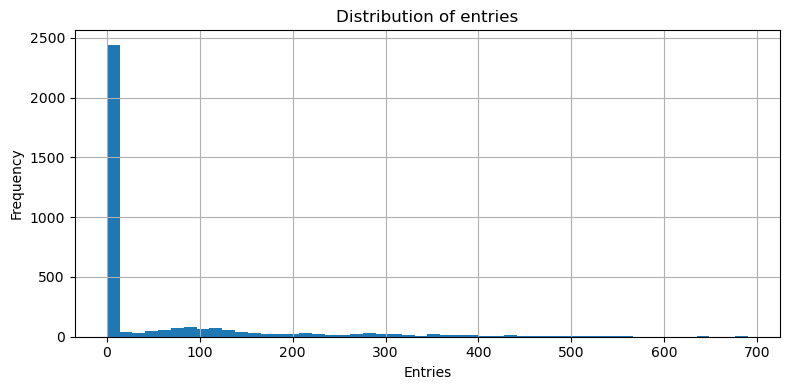

In [18]:
low_volume_rows = route_daily[route_daily["entries"] < 10].copy()
low_volume_rows[["date", "route_city", "entries", "investigated", "flagged", "flag_rate"]].head(20)

route_daily["entries"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
plt.figure(figsize=(8, 4))
route_daily["entries"].dropna().hist(bins=50)
plt.title("Distribution of entries")
plt.xlabel("Entries")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [19]:
fill_zero_cols = ["case_records","total_flights","unique_alarm_reasons","unique_event_types"]

for col in fill_zero_cols:
    if col in route_daily.columns:
        route_daily[col] = route_daily[col].fillna(0)

In [20]:
route_daily["alarm_density_per_entry"] = np.where(route_daily["entries"] > 0, route_daily["case_records"] / route_daily["entries"], np.nan)

Since 'flagged_pct_change1' and 'flag_rate_pct_change1' contains so many missing values (more than 50% they must be dropped).

In [21]:
route_daily.drop(columns=['flagged_pct_change1', 'flag_rate_pct_change1'], inplace=True, errors='ignore')

In [22]:
missing_report = (
    route_daily.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_report.head(30)

,column,missing_pct
0,investigation_rate_pct_change1,0.191185
1,investigated_pct_change1,0.190893
2,flag_rate_diff1,0.157034
3,investigation_rate_diff1,0.157034
4,flag_rate_lag1,0.156743
5,investigation_rate_lag1,0.156743
6,entries_pct_change1,0.156743
7,entries_lag1,0.156159
8,investigated_lag1,0.156159
9,investigated_diff1,0.156159


In [23]:
route_daily["is_low_volume"] = (route_daily["entries"] < 10).astype(int)
route_daily["is_low_volume_50"] = (route_daily["entries"] < 50).astype(int)
print("Rows with entries < 10:", route_daily["is_low_volume"].sum())
print("Rows with entries < 50:", route_daily["is_low_volume_50"].sum())

Rows with entries < 10: 2418
Rows with entries < 50: 2530


In [24]:
full_feature_cols = (cfg.ID_COLS + cfg.CALENDAR_COLS + cfg.BASE_COLS + cfg.SEGMENT_COLS + cfg.CASE_COLS + cfg.CHANGE_COLS + cfg.VOLUME_FLAG_COLS)
full_feature_cols = [column for column in full_feature_cols if column in route_daily.columns]

feature_engineered_full = route_daily[full_feature_cols].copy()

print(feature_engineered_full.shape)
feature_engineered_full.head()

(3426, 56)


,date,route_city,route_country,route_airport,year,month,day,weekday,is_weekend,entries,...,investigated_pct_change1,flagged_lag1,flagged_diff1,investigation_rate_lag1,investigation_rate_diff1,investigation_rate_pct_change1,flag_rate_lag1,flag_rate_diff1,is_low_volume,is_low_volume_50
0,2024-02-03,ABIDJAN_CAGLIARI,CIV_ITA,ABJ_CAG,2024,2,3,5,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,2024-01-08,SMIRNE_BERGAMO,TUR_ITA,ADB_BGY,2024,1,8,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,2024-02-01,SMIRNE_ROMA,TUR_ITA,ADB_FCO,2024,2,1,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
3,2024-01-01,SMIRNE_MILANO,TUR_ITA,ADB_MXP,2024,1,1,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,2024-01-15,SMIRNE_MILANO,TUR_ITA,ADB_MXP,2024,1,15,0,0,2,...,1.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,1,1


In [28]:
feature_engineered_full.to_csv(cfg.FEAT_ENGEERING_OUT, index=False)